<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_04_Pandas Pivot Tables.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
df = pd.read_csv("hf://datasets/lukebarousse/data_jobs/data_jobs.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## 🟩 Count Job Postings by Title and Country (2.4.1)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [4]:
df_pivot=df.pivot_table(index='job_country', columns='job_title_short', values='salary_year_avg', aggfunc='count')

<Axes: >

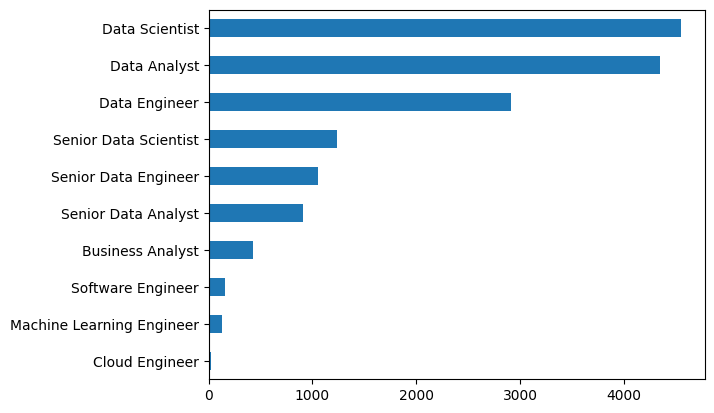

In [11]:
df_pivot.loc['United States'].sort_values(ascending=True).plot(kind='barh', ylabel='')

---

## 🟨 Salary Stats by Job Title (2.4.2)

In [26]:


df_1 = df.pivot_table(index='job_title_short', values='salary_year_avg', aggfunc=['median', 'mean', 'min', 'max', 'std', 'count'])
df_1

,median,mean,min,max,std,count
,salary_year_avg,salary_year_avg,salary_year_avg,salary_year_avg,salary_year_avg,salary_year_avg
job_title_short,,,,,,
Business Analyst,85000.0,91082.612833,16500.0,387460.0,32036.098388,610
Cloud Engineer,90000.0,111268.453846,42000.0,280000.0,50514.351080,65
Data Analyst,90000.0,93841.907854,25000.0,650000.0,34100.108034,5451
Data Engineer,125000.0,130125.604250,15000.0,525000.0,42525.929674,4500
Data Scientist,127500.0,135988.837171,27000.0,960000.0,52227.832196,5922
Machine Learning Engineer,106415.0,126774.315972,30000.0,325000.0,53914.993342,576
Senior Data Analyst,111175.0,113911.363665,30000.0,425000.0,34060.065096,1131
Senior Data Engineer,147500.0,145840.611624,35000.0,425000.0,37415.120392,1591


<Axes: >

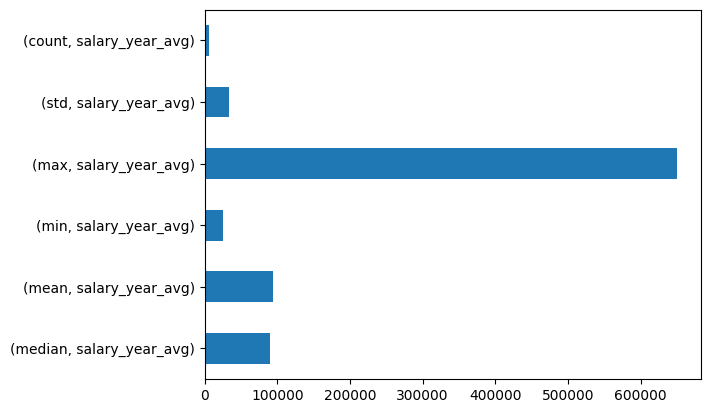

In [28]:
df_1.loc['Data Analyst'].plot(kind='barh')

---

## 🟥 Sum Salary by Title and Country (2.4.3)

In [21]:
df.pivot_table(index='job_country', values='salary_year_avg', columns='job_title_short', aggfunc='sum')

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Afghanistan,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN
Albania,0.0,0.0,99900.0,0.0,139962.5,0.0,0.0,0.0,157500.0,0.0
Algeria,0.0,0.0,44100.0,45000.0,0.0,0.0,NaN,0.0,NaN,0.0
Angola,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0
Argentina,142200.0,197500.0,341745.5,1225599.0,597221.5,393029.0,0.0,295000.0,0.0,174500.0
...,...,...,...,...,...,...,...,...,...,...
Venezuela,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Vietnam,223200.0,0.0,999267.0,1576131.0,534400.0,571050.0,402050.0,508500.0,79200.0,107200.0
Yemen,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0


In [30]:
unique_countries = df.job_country.unique()
countries_starting_with_u = [country for country in unique_countries if isinstance(country, str) and country.startswith('U')]
print(countries_starting_with_u)

['United States', 'United Kingdom', 'Uruguay', 'Ukraine', 'United Arab Emirates', 'U.S. Virgin Islands', 'Uganda', 'Uzbekistan']


---